/home/ebertp/work/code/cubi/project-chrom-y-extended/codebase/postproc-region-labels/notebooks


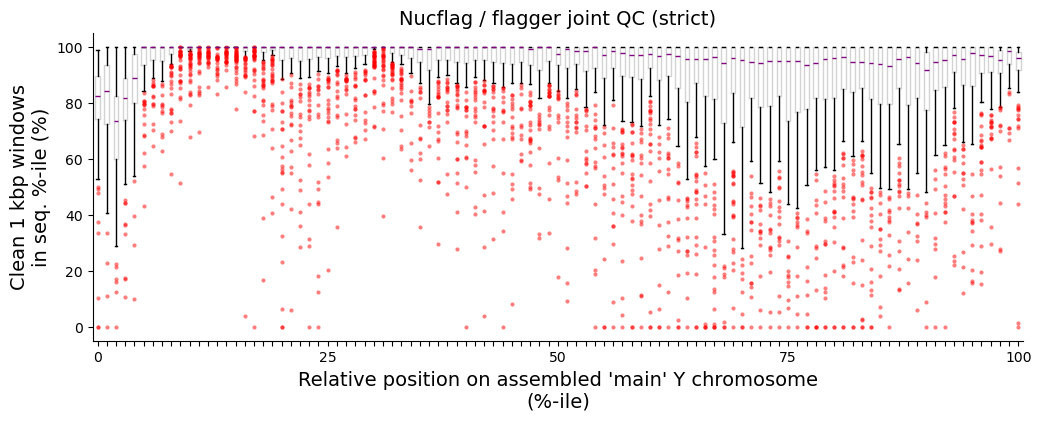

In [160]:
import pathlib as pl
import pandas as pd
import functools as fnt
import json
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt

print(pl.Path(".").resolve())

stats_folder = pl.Path("/home/ebertp/work/projects/chrom-y-extended/wf-data/region-labels/check_qc")

merged = dict()
for json_file in stats_folder.glob("*.json"):
    with open(json_file) as dump:
        data = json.load(dump)
        merged[data["sample"]] = data


plot_stat = "strict"

plot_qnt = np.zeros((len(merged), 101), dtype=float)

for row, (sample, sample_data) in enumerate(merged.items(), start=0):
    sample_stats = sample_data["by-location|main"]
    for col in range(0,101):
        if plot_stat == "strict":
            value = sample_stats[str(col)].get("clean_both_pct", 0.)
        elif plot_stat == "lenient":
            v1 = sample_stats[str(col)].get("clean_both_pct", 0.)
            v2 = sample_stats[str(col)].get("clean_any_pct", 0.)
            value = v1 + v2
        else:
            raise ValueError(plot_stat)
        plot_qnt[row, col] = value


fig, ax = plt.subplots(figsize=(12,4))

flierprops = {
    "alpha": 0.5,
    "marker": ".",
    "markerfacecolor": "red",
    "markeredgecolor": "None"
}

medianprops = {
    "color": "purple"
}

boxprops = {
    "color": "lightgrey"
}

_ = ax.boxplot(plot_qnt, flierprops=flierprops, medianprops=medianprops, boxprops=boxprops)
_ = ax.set_xlabel("Relative position on assembled 'main' Y chromosome\n(%-ile)", fontsize=14)
_ = ax.set_xticklabels([f"{i}" if i % 25 == 0 else "" for i in range(0,101)])
_ = ax.set_ylabel("Clean 1 kbp windows\nin seq. %-ile (%)", fontsize=14)

_ = ax.spines["top"].set_visible(False)
_ = ax.spines["right"].set_visible(False)

_ = ax.set_title(f"Nucflag / flagger joint QC ({plot_stat})", fontsize=14)

plt.savefig("nucflag-flagger_joint_mainY.png", dpi=150)
